# McCann interpolation between cat and heart shapes

This notebook generates `fig:monge-shape-mccann-interpolation`.  The source and target are binary shapes loaded from `assets/cat.png` and `assets/heart.jpg`.  After sampling equal-weight point clouds, POT computes the quadratic assignment.  McCann interpolation moves particles along
$$
T_t(x_i)=(1-t)x_i+tT(x_i),\qquad \alpha_t=(T_t)_\sharp\alpha_n.
$$
The first row displays a farthest-point subset of particles; the second row displays the denser transported cloud as a saturated color density image, with white for zero density and a red-to-blue interpolation for high density.


In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        ROOT = candidate.parent if candidate.name == "notebooks-figures" else candidate
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot
from PIL import Image
from scipy.ndimage import gaussian_filter

from figure_style import BLUE, RED, interp_color, figure_dir, remove_axes, save_pdf, setup_matplotlib

setup_matplotlib()
rng = np.random.default_rng(20240608)
ASSETS = ROOT / "notebooks-figures" / "assets"


## Shape sampling and barycentric map

The OT solve uses many more particles than are displayed.  The displayed particles are a farthest-point subset, while the density panels use the denser cloud to reduce sampling artifacts.

In [2]:
def load_shape_points(path, n_candidates=16000):
    img = Image.open(path).convert("RGBA")
    arr = np.asarray(img, dtype=float) / 255.0
    rgb = arr[..., :3]
    alpha = arr[..., 3]
    luminance = rgb.mean(axis=2)
    mask = (alpha > 0.25) & (luminance < 0.65)
    ys, xs = np.nonzero(mask)
    pts = np.column_stack([xs, -ys]).astype(float)
    pts += rng.uniform(-0.45, 0.45, size=pts.shape)
    lo = pts.min(axis=0)
    hi = pts.max(axis=0)
    pts = 2 * (pts - lo) / (hi - lo).max() - 1
    pts -= pts.mean(axis=0, keepdims=True)
    if len(pts) > n_candidates:
        pts = pts[rng.choice(len(pts), n_candidates, replace=False)]
    return pts


def random_shape_sample(points, n):
    idx = rng.choice(len(points), n, replace=False)
    return points[idx]


def farthest_subset(points, n):
    points = np.asarray(points)
    chosen = [int(np.argmin(np.sum(points**2, axis=1)))]
    dist2 = np.sum((points - points[chosen[0]]) ** 2, axis=1)
    for _ in range(1, n):
        i = int(np.argmax(dist2))
        chosen.append(i)
        dist2 = np.minimum(dist2, np.sum((points - points[i]) ** 2, axis=1))
    return np.asarray(chosen)

cat_candidates = load_shape_points(ASSETS / "cat.png")
heart_candidates = load_shape_points(ASSETS / "heart.jpg")

n_dense = 2200
source_dense = cat_candidates[farthest_subset(cat_candidates, n_dense)]
target_dense = heart_candidates[farthest_subset(heart_candidates, n_dense)]
# Move the shapes slightly apart before OT, then center the full interpolation for display.
source_dense[:, 0] -= 0.18
target_dense[:, 0] += 0.18

a = np.ones(n_dense) / n_dense
b = np.ones(n_dense) / n_dense
C = ot.dist(source_dense, target_dense, metric="sqeuclidean")
P = ot.emd(a, b, C, numItermax=500000)
T_dense = (P @ target_dense) / a[:, None]

display_idx = farthest_subset(source_dense, 165)
source_display = source_dense[display_idx]
T_display = T_dense[display_idx]

times = [0.0, 0.25, 0.5, 0.75, 1.0]
all_points = np.vstack([source_dense, T_dense])
center = all_points.mean(axis=0)
source_dense -= center
T_dense -= center
source_display -= center
T_display -= center


## Exported particle and density panels

The density panels are kernel-smoothed histograms of the transported dense cloud.  They are rendered as images rather than level sets: zero density is white, while the color reaches full saturation at the 95th percentile of the nonzero density values to make the support readable.


In [3]:
NAME = "monge-shape-mccann-interpolation"
OUT = figure_dir(NAME)

def density_image(points, grid_lim=1.36, bins=220, sigma=2.15):
    H, xedges, yedges = np.histogram2d(points[:, 0], points[:, 1], bins=bins, range=[[-grid_lim, grid_lim], [-grid_lim, grid_lim]])
    H = gaussian_filter(H.T, sigma=sigma)
    return H, (xedges[0], xedges[-1], yedges[0], yedges[-1])


def color_density_image(H, color):
    color = np.asarray(color, dtype=float)
    vals = H[H > 0]
    scale = np.percentile(vals, 95) if len(vals) else 1.0
    v = np.clip(H / max(scale, 1e-12), 0, 1)
    return (1 - v[..., None]) * np.ones((*H.shape, 3)) + v[..., None] * color

for t in times:
    suffix = f"t{int(round(100*t)):03d}"
    color = interp_color(t)
    pts = (1 - t) * source_display + t * T_display
    dense = (1 - t) * source_dense + t * T_dense

    fig, ax = plt.subplots(figsize=(1.55, 1.55))
    ax.scatter(pts[:, 0], pts[:, 1], s=5.8, color=color, edgecolor="none", linewidth=0)
    ax.set_xlim(-1.34, 1.34)
    ax.set_ylim(-1.34, 1.34)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, OUT / f"particles-{suffix}.pdf", pad_inches=0.006)
    plt.close(fig)

    H, extent = density_image(dense)
    fig, ax = plt.subplots(figsize=(1.55, 1.55))
    ax.imshow(color_density_image(H, color), extent=extent, origin="lower", interpolation="bicubic")
    ax.set_xlim(-1.34, 1.34)
    ax.set_ylim(-1.34, 1.34)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, OUT / f"density-{suffix}.pdf", pad_inches=0.006)
    plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


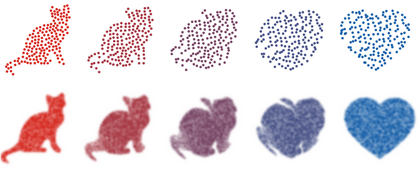

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/monge-shape-mccann-interpolation.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/monge-shape-mccann-interpolation.png")
display(Image(filename=str(_thumb)))
